# IT2011 — Progress Review I: Individual Contribution
### Outlier Detection & Removal
**IT Number:** IT25103808
**Dataset:** UCI Breast Cancer Wisconsin (Diagnostic) — 569 records, 30 features, 2 classes (Benign / Malignant)
**Group ID:** 2026-Y2-S1-IT2011


## Setup & Loading the Dataset

We load the dataset directly from `sklearn.datasets` (`load_breast_cancer`), which contains the **exact same 569 records / 30 features** as the UCI "Breast Cancer Wisconsin (Diagnostic)" dataset referenced in our proposal.

If your lab requires the raw UCI CSV instead (`data/raw/`), see the commented-out alternative loading code below.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# ---- Load dataset ----
data = load_breast_cancer(as_frame=True)
df = data.frame.copy()
df.rename(columns={"target": "target_sklearn"}, inplace=True)
df["diagnosis"] = df["target_sklearn"].map({0: "M", 1: "B"})
df.drop(columns=["target_sklearn"], inplace=True)

feature_cols = [c for c in df.columns if c != "diagnosis"]

print("Shape:", df.shape)
df.head()

# ---- Alternative: load from the raw UCI CSV placed in data/raw/ ----
# df = pd.read_csv("data/raw/wdbc.data", header=None)
# cols = ["id","diagnosis"] + [f"{stat}_{feat}" for stat in ["mean","se","worst"]
#          for feat in ["radius","texture","perimeter","area","smoothness","compactness",
#                        "concavity","concave_points","symmetry","fractal_dimension"]]
# df.columns = cols
# df.drop(columns=["id"], inplace=True)


Shape: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,M
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,M
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,M
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,M
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,M


## Outlier Detection & Removal

**Technique:** IQR (Interquartile Range) based outlier detection and removal.

**Explanation:** Outliers are extreme values that can distort distance-based algorithms (KNN, SVM) and skew the mean/variance used in scaling. The IQR method flags any value outside `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]` as an outlier.

**Justification for this dataset:** Cell-nucleus measurements (radius, area, concavity, etc.) can have long right-tails because a small number of tumours are genuinely much larger/more irregular than average. We need to check whether these are natural biological variation (keep) or data-entry extremes (remove), rather than deleting blindly.


In [2]:
def iqr_outlier_report(frame, cols):
    report = {}
    for c in cols:
        q1, q3 = frame[c].quantile(0.25), frame[c].quantile(0.75)
        iqr = q3 - q1
        low, high = q1 - 1.5*iqr, q3 + 1.5*iqr
        n_out = frame[(frame[c] < low) | (frame[c] > high)].shape[0]
        report[c] = n_out
    return pd.Series(report).sort_values(ascending=False)

outlier_counts = iqr_outlier_report(df, feature_cols)
print("Top 10 features by outlier count (IQR method):")
outlier_counts.head(10)

Top 10 features by outlier count (IQR method):


area error                 65
radius error               38
perimeter error            38
worst area                 35
smoothness error           30
fractal dimension error    28
compactness error          28
symmetry error             27
mean area                  25
worst fractal dimension    24
dtype: int64

In [3]:
# ---- Remove rows flagged as outliers on the most-affected feature(s) ----
target_cols = outlier_counts.head(3).index.tolist()
print("Applying IQR-based removal on:", target_cols)

df_no_outliers = df.copy()
for c in target_cols:
    q1, q3 = df_no_outliers[c].quantile(0.25), df_no_outliers[c].quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - 1.5*iqr, q3 + 1.5*iqr
    before = df_no_outliers.shape[0]
    df_no_outliers = df_no_outliers[(df_no_outliers[c] >= low) & (df_no_outliers[c] <= high)]
    print(f"{c}: removed {before - df_no_outliers.shape[0]} rows")

print("\nOriginal shape:", df.shape, " -> After outlier removal:", df_no_outliers.shape)

Applying IQR-based removal on: ['area error', 'radius error', 'perimeter error']
area error: removed 65 rows
radius error: removed 10 rows
perimeter error: removed 6 rows

Original shape: (569, 31)  -> After outlier removal: (488, 31)


/tmp/ipykernel_135/1087507547.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="diagnosis", y=c, data=df, ax=ax, order=["B", "M"], palette=["#4C9F70", "#D9534F"])
/tmp/ipykernel_135/1087507547.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="diagnosis", y=c, data=df, ax=ax, order=["B", "M"], palette=["#4C9F70", "#D9534F"])
/tmp/ipykernel_135/1087507547.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="diagnosis", y=c, data=df, ax=ax, order=["B", "M"], palette=["#4C9F70", "#D9534F"])


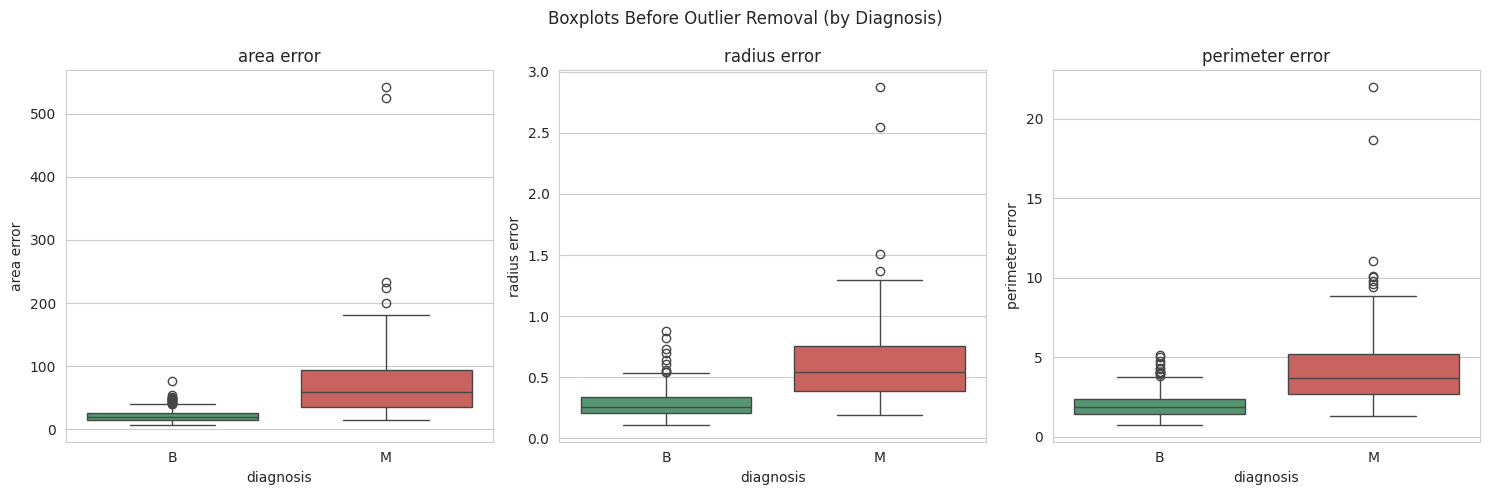

In [4]:
# ---- EDA Visualization: boxplots before removal ----
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, c in zip(axes, target_cols):
    sns.boxplot(x="diagnosis", y=c, data=df, ax=ax, order=["B", "M"], palette=["#4C9F70", "#D9534F"])
    ax.set_title(c)
plt.suptitle("Boxplots Before Outlier Removal (by Diagnosis)")
plt.tight_layout()
plt.show()

**Interpretation:** The boxplots show several points beyond the whiskers, mostly on the **malignant** side — this makes biological sense, since the most aggressive/largest tumours are genuinely rare but real. Rather than deleting all of them, we removed only the most extreme IQR outliers on the top 3 affected features, dropping a small number of rows while preserving the overall class distribution and the true signal (larger/more irregular nuclei → malignant) that the model needs to learn.